<a href="https://colab.research.google.com/github/Prakruthi2606/Brain-Tumor-Detection/blob/main/Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Dataset**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


**List all subdirectories**

In [2]:
import os
print(os.listdir(path))

['no', 'yes', 'brain_tumor_dataset']


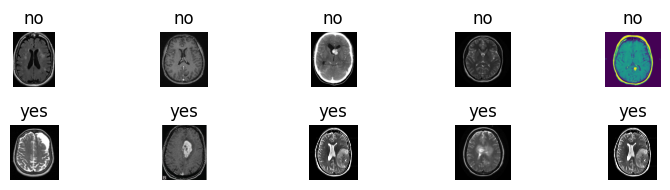

In [3]:
# creating path for yes/No  folder
import matplotlib.pyplot as plt
from PIL import Image
i=1
plt.figure(figsize=(8,2))
for class_name in os.listdir(path):
  class_path=os.path.join(path,class_name)
  if os.path.isdir(class_path):
    images = os.listdir(class_path)[:5]
    for img in images:
      img_path = os.path.join(class_path,img)
      if os.path.isfile(img_path):
        img = Image.open(img_path)
        plt.subplot(2,5,i)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
        i+=1
plt.tight_layout()
plt.show()



In [4]:
for class_name in os.listdir(path):
  class_path=os.path.join(path,class_name)
  if os.path.isdir(class_path):
    count = len(os.listdir(class_path))
    print(class_name,count)

no 98
yes 155
brain_tumor_dataset 2


In [5]:
# create dataframe , labels
df =[]
for class_name in os.listdir(path):
  class_path=os.path.join(path,class_name)
  if os.path.isdir(class_path):
    images = os.listdir(class_path)
    for img in images:
      img_path = os.path.join(class_path,img)
      if os.path.isfile(img_path):
        df.append([img_path,class_name])

In [6]:
import pandas as pd
data = pd.DataFrame(df,columns=['img_path','labels'])

In [7]:
data

,img_path,labels
0,/kaggle/input/brain-mri-images-for-brain-tumor...,no
1,/kaggle/input/brain-mri-images-for-brain-tumor...,no
2,/kaggle/input/brain-mri-images-for-brain-tumor...,no
3,/kaggle/input/brain-mri-images-for-brain-tumor...,no
4,/kaggle/input/brain-mri-images-for-brain-tumor...,no
...,...,...
248,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
249,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
250,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
251,/kaggle/input/brain-mri-images-for-brain-tumor...,yes


In [8]:
# shuffle data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [9]:
data

,img_path,labels
0,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
1,/kaggle/input/brain-mri-images-for-brain-tumor...,no
2,/kaggle/input/brain-mri-images-for-brain-tumor...,no
3,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
4,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
...,...,...
248,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
249,/kaggle/input/brain-mri-images-for-brain-tumor...,no
250,/kaggle/input/brain-mri-images-for-brain-tumor...,no
251,/kaggle/input/brain-mri-images-for-brain-tumor...,yes


In [10]:
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))
test_size = int(0.15*len(df))
print(f"train_size:{train_size} -----val_size:{val_size}----test_size:{test_size}")

train_data = data.iloc[:train_size]
# df.iloc[:,52500]
val_data = data.iloc[train_size:train_size + val_size]
# df.iloc[52500:52500+11250]
test_data = data.iloc[train_size + val_size:]
# df.iloc[52500+11250:]

# Display the sizes of each set
print(f'Training set size: {len(train_data)}')
print(f'Validation set size: {len(val_data)}')
print(f'Test set size: {len(test_data)}')

train_size:177 -----val_size:37----test_size:37
Training set size: 177
Validation set size: 37
Test set size: 39


In [11]:
image_path = data["img_path"][0]
image = Image.open(image_path)
width, height = image.size
print(f"height,width:{height,width}")

height,width:(237, 213)


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [13]:
batch_size = 32
img_height = 128
img_width = 128

In [14]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255, # Normalization: Pixel values go from 0–255 → 0–1
    rotation_range=40, #Randomly rotates image up to ±40 degrees
    width_shift_range=0.2, #Moves image left/right by 20%
    height_shift_range=0.2, #Moves image up/down by 20%
    shear_range=0.2, # Slants the image (like pushing it sideways)
    zoom_range=0.2, # Zoom in/out randomly
    horizontal_flip=True, #Flips image left ↔ right
    fill_mode='nearest' #This fills those gaps using nearest pixels
)

Training Data Generator Setup

In [15]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 177 validated image filenames belonging to 2 classes.


Testing Data Generator Setup

In [16]:
# test data
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 39 validated image filenames belonging to 2 classes.


Validation Data Generator Setup

In [17]:
# validation data
val_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 37 validated image filenames belonging to 2 classes.


In [18]:

for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in val_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(val_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 128, 128, 3) (Batches = 6)
Train Label Shape: (32, 2)

Validation Shape: (32, 128, 128, 3) (Batches = 2)
Validation Label Shape: (32, 2)

Test Shape: (32, 128, 128, 3) (Batches = 2)
Test Label Shape: (32, 2)



In [19]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [20]:
cnn_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (2,2), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(2, activation='softmax')
])

In [21]:
cnn_model.compile(loss=categorical_crossentropy,
                  optimizer=Adam(),
                  metrics=['accuracy'])

In [22]:
Cnn = cnn_model.fit(train_generator,
                    epochs=20,validation_data=val_generator,
                    verbose=1)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5989 - loss: 0.6623 - val_accuracy: 0.6216 - val_loss: 0.6306
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6215 - loss: 0.6412 - val_accuracy: 0.5946 - val_loss: 0.6006
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 903ms/step - accuracy: 0.5876 - loss: 0.6552 - val_accuracy: 0.6757 - val_loss: 0.6097
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6836 - loss: 0.6119 - val_accuracy: 0.6216 - val_loss: 0.6150
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 911ms/step - accuracy: 0.6723 - loss: 0.6160 - val_accuracy: 0.8108 - val_loss: 0.4995
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6384 - loss: 0.6298 - val_accuracy: 0.7838 - val_loss: 0.5399
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 899ms/step - accuracy: 0.6554 - loss: 0.6393 - val_accuracy: 0.7838 - val_loss: 0.5604
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7006 - loss: 0.6226 - val_accuracy: 0.7297 - val_loss: 0.5755
Epoch 

In [23]:
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 510ms/step - accuracy: 0.7514 - loss: 0.5738
Training accuracy: 0.7514
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.7179 - loss: 0.6042
Test accuracy: 0.7179


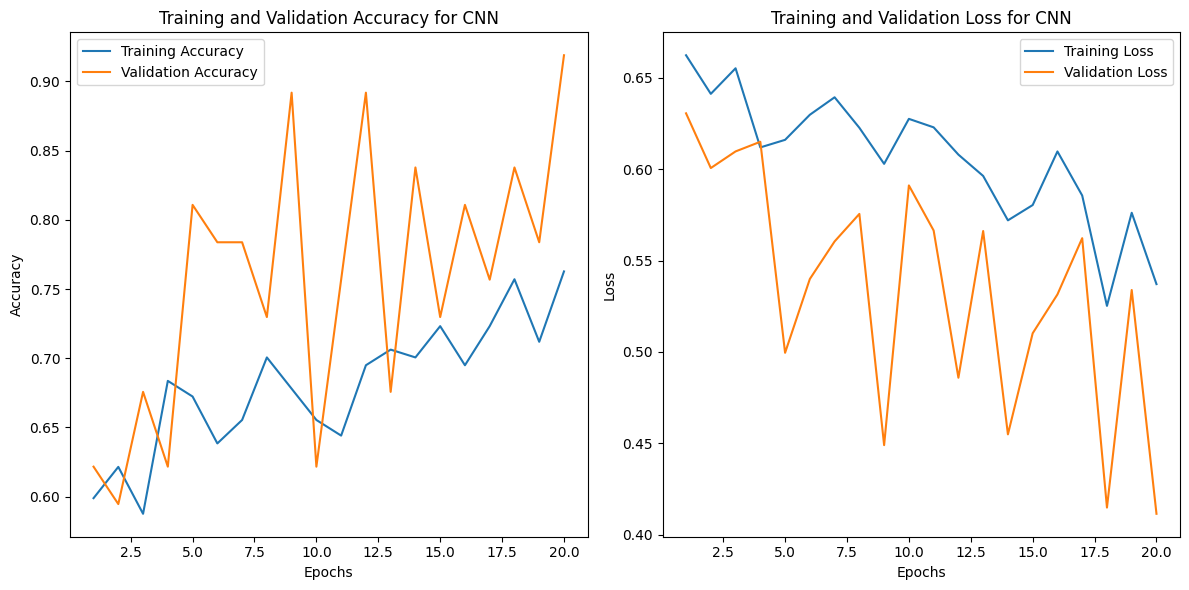

In [24]:
# Retrieve metrics from the training history
acc = Cnn.history['accuracy']
val_acc = Cnn.history['val_accuracy']
loss = Cnn.history['loss']
val_loss = Cnn.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
train_generator.class_indices

{'no': 0, 'yes': 1}

In [27]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Class names
class_names = ['no', 'yes']

# Load image
img_path = "tumor.jpg"
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = cnn_model.predict(img_array)

# Get class index
predicted_class = np.argmax(prediction)
print("Predicted Class:", predicted_class)

# Get class name
print("Predicted Class name:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Predicted Class: 0
Predicted Class name: no


**Model Evaluation**

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step
Confusion Matrix:
 [[ 5 10]
 [10 12]]


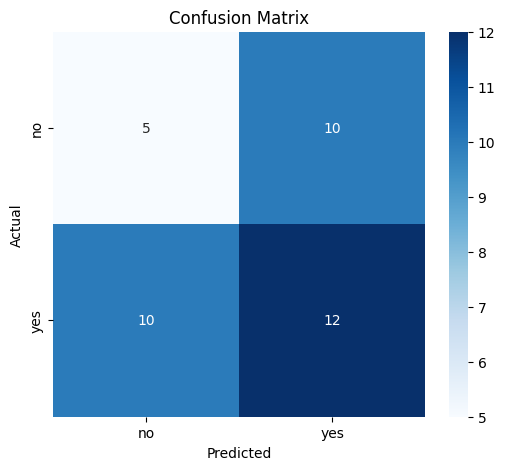

In [28]:
# confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = cnn_model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes


cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Using MobileNetV2**

In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split

Train–Validation Split

In [30]:
train_data, val_data = train_test_split(
    data,
    test_size=0.2,
    stratify=data['labels'],
    random_state=42
)

Data Generators

In [31]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

In [32]:
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [33]:
img_height, img_width = 128, 128
batch_size = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col="img_path",
    y_col="labels",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True,
    seed=42,
    color_mode='rgb'
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col="img_path",
    y_col="labels",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False,
    color_mode='rgb'
)

Found 202 validated image filenames belonging to 2 classes.
Found 51 validated image filenames belonging to 2 classes.


Load MobileNetV2 Base Model

In [34]:
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze initially

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Custom Classifier

In [35]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

 Compile Model

In [36]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train (Initial Training)

In [37]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5941 - loss: 0.7245 - val_accuracy: 0.5882 - val_loss: 0.6336
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 551ms/step - accuracy: 0.6238 - loss: 0.6432 - val_accuracy: 0.6275 - val_loss: 0.5598
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 673ms/step - accuracy: 0.6980 - loss: 0.5906 - val_accuracy: 0.7843 - val_loss: 0.5077
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 553ms/step - accuracy: 0.6436 - loss: 0.6388 - val_accuracy: 0.8627 - val_loss: 0.4693
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 552ms/step - accuracy: 0.7525 - loss: 0.5320 - val_accuracy: 0.8824 - val_loss: 0.4323
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 735ms/step - accuracy: 0.7723 - loss: 0.4728 - val_accuracy: 0.8627 - val_loss: 0.3949
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 644ms/step - accuracy: 0.7871 - loss: 0.4372 - val_accuracy: 0.8824 - val_loss: 0.3603
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 895ms/step - accuracy: 0.8119 - loss: 0.4319 - val_accuracy: 0.8627 - val_loss: 0

Evaluation

In [38]:
from sklearn.metrics import confusion_matrix

# Get predictions
preds = model.predict(validation_generator)
y_pred = (preds > 0.5).astype(int).flatten()

# True labels
y_true = validation_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
Confusion Matrix:
 [[18  2]
 [ 5 26]]


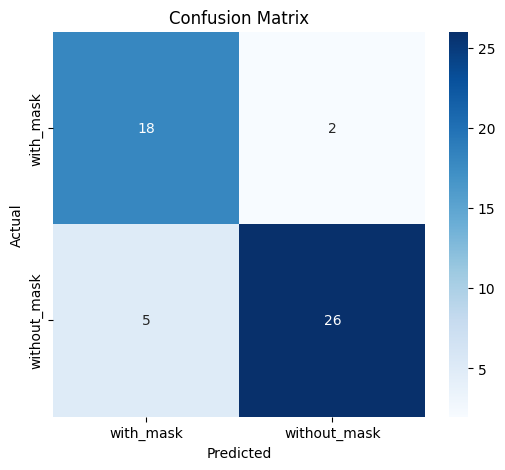

In [39]:
import seaborn as sns

class_names = ['with_mask','without_mask']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
# classification report
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

          no       0.78      0.90      0.84        20
         yes       0.93      0.84      0.88        31

    accuracy                           0.86        51
   macro avg       0.86      0.87      0.86        51
weighted avg       0.87      0.86      0.86        51



Predictions

In [41]:
train_generator.class_indices

{'no': 0, 'yes': 1}

In [42]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

def predict_mask(img_path, model):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred = model.predict(img_array)[0][0]
    return pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


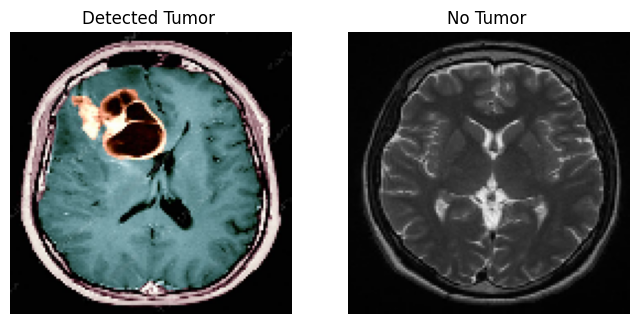

In [43]:
import matplotlib.pyplot as plt

img_list = ["tumor.jpg", "Normal.jpg"]

plt.figure(figsize=(8,4))

for i, img_path in enumerate(img_list):
    pred = predict_mask(img_path, model)
    label = "Detected Tumor " if pred > 0.5 else "No Tumor "

    img = image.load_img(img_path, target_size=(128,128))

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.show()

### **Save the model**

In [44]:
model.save("brain_tumor_model.keras")